<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/WEEK_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **C VINUSHA REDDY**

 **1CR22IS036**


###  Problem Statement

Employee attrition is a critical issue for organizations, leading to increased hiring costs, productivity loss, and reduced employee morale.

In this project, the goal is to build a **Machine Learning classification model** that predicts whether an employee will leave the company (**Attrition: Yes/No**) based on features such as:

- Age  
- Salary  
- Job Role  
- Job Satisfaction  
- Work Experience  
- Overtime  
- Work-Life Balance  
- Department  

Students are required to analyze the dataset, preprocess the data, perform feature engineering, train multiple classification models, and evaluate their performance to identify the best model for predicting employee attrition.

### Objective

The objective of this task is to:

- Understand and explore the HR dataset  
- Perform data preprocessing (missing values, duplicates, outliers)  
- Conduct Exploratory Data Analysis (EDA)  
- Apply encoding and feature scaling  
- Train multiple classification algorithms  
- Evaluate models using classification metrics  
- Perform cross-validation and hyperparameter tuning  
- Select the best-performing model  

### 1. Import Libraries

In [ ]:
#1. Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

### 2. Load Dataset

In [ ]:
data = pd.read_csv('HR-Employee-Attrition.csv')   # upload your dataset in Colab
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Understanding Variables


- Age – Age of the employee in years.

- Attrition – Whether the employee left the company (Yes = Left, No = Stayed).

- BusinessTravel – Frequency of business travel (Travel_Rarely, Travel_Frequently, Non-Travel).

- DailyRate – Daily earning rate of the employee.

- Department – Department where the employee works (Sales, HR, R&D).

- DistanceFromHome – Distance between home and workplace.

- Education – Education level (1 = Below College, 5 = Doctor).

- EducationField – Field of education (Medical, Technical, Marketing, etc.).

- EmployeeCount – Count of employees (constant value, not useful).

- EmployeeNumber – Unique ID assigned to each employee.

- EnvironmentSatisfaction – Satisfaction with work environment (1 = Low, 4 = High).

- Gender – Gender of the employee (Male, Female).

- HourlyRate – Hourly earning rate.

- JobInvolvement – Level of involvement in job (1 = Low, 4 = High).

- JobLevel – Job level in the organization (higher value = senior position).

- JobRole – Role/designation of the employee.

- JobSatisfaction – Job satisfaction level (1 = Low, 4 = High).

- MaritalStatus – Marital status (Single, Married, Divorced).

- MonthlyIncome – Monthly salary of the employee.

- MonthlyRate – Monthly rate (internal metric, not directly meaningful).

- NumCompaniesWorked – Number of companies the employee has worked for.

- Over18 – Whether employee is over 18 (always Yes, not useful).

- OverTime – Whether the employee works overtime (Yes/No).

- PercentSalaryHike – Percentage increase in salary.

- PerformanceRating – Performance rating (1–4 scale).

- RelationshipSatisfaction – Satisfaction with workplace relationships (1–4).

- StandardHours – Standard working hours (constant, not useful).

- StockOptionLevel – Stock option level provided to employee.

- TotalWorkingYears – Total years of work experience.

- TrainingTimesLastYear – Number of trainings attended in last year.

- WorkLifeBalance – Work-life balance rating (1 = Poor, 4 = Best).

- YearsAtCompany – Number of years at current company.

- YearsInCurrentRole – Years in current job role.

- YearsSinceLastPromotion – Years since last promotion.

- YearsWithCurrManager – Years working with current manager.

### 3. Basic Checks

In [ ]:
print(data.shape)
print(data.columns)
print(data.dtypes)
data.describe()

(1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              objec

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 4. Missing Values

In [ ]:
data.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


### 5. Duplicates

In [ ]:
data.duplicated().sum()

np.int64(0)

### 6. Univariate Analysis

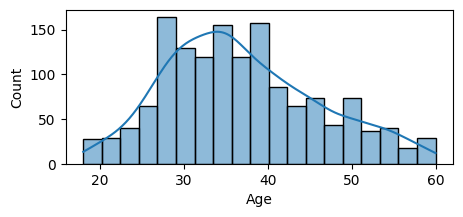

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data, x='Age', kde=True)
plt.show()

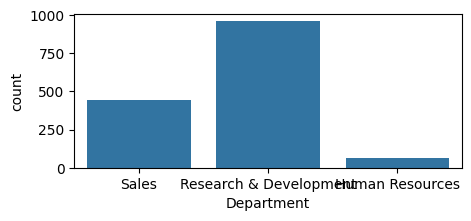

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data, x='Department')
plt.show()

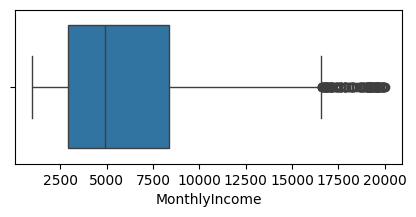

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(data, x='MonthlyIncome')
plt.show()

### 7. Bivariate Analysis

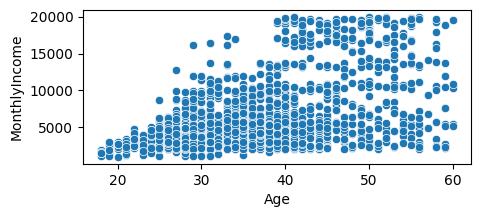

In [ ]:
plt.figure(figsize=(5,2))
sns.scatterplot(data=data, x='Age', y='MonthlyIncome')
plt.show()

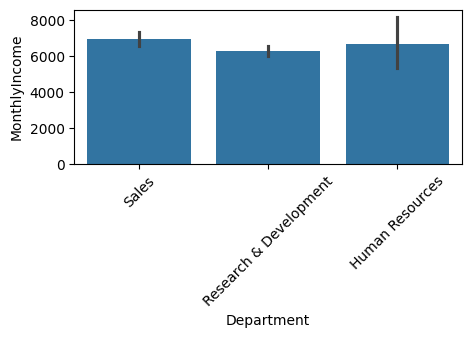

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data=data, x='Department', y='MonthlyIncome')
plt.xticks(rotation=45)
plt.show()

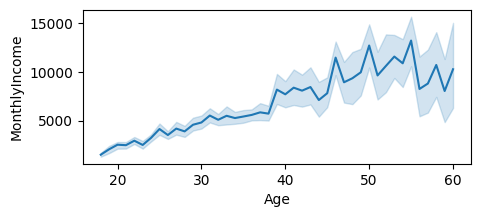

In [ ]:
plt.figure(figsize=(5,2))
sns.lineplot(data=data, x='Age', y='MonthlyIncome')
plt.show()

### 8. Correlation Heatmap

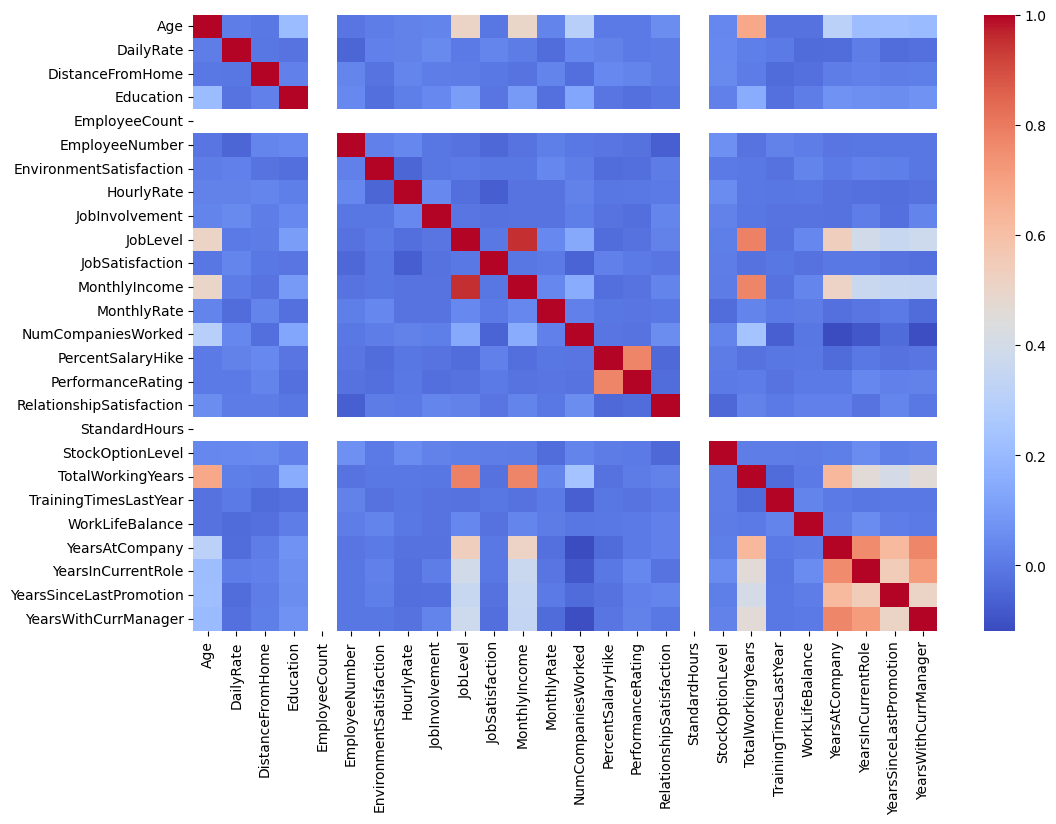

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.show()


###9. Outlier Handling

### 1.Check outliers in numerical columns



In [ ]:
num_cols = data.select_dtypes(include=['number']).columns
num_cols

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

### 2. Checking the outliers of the numerical columns in box plot


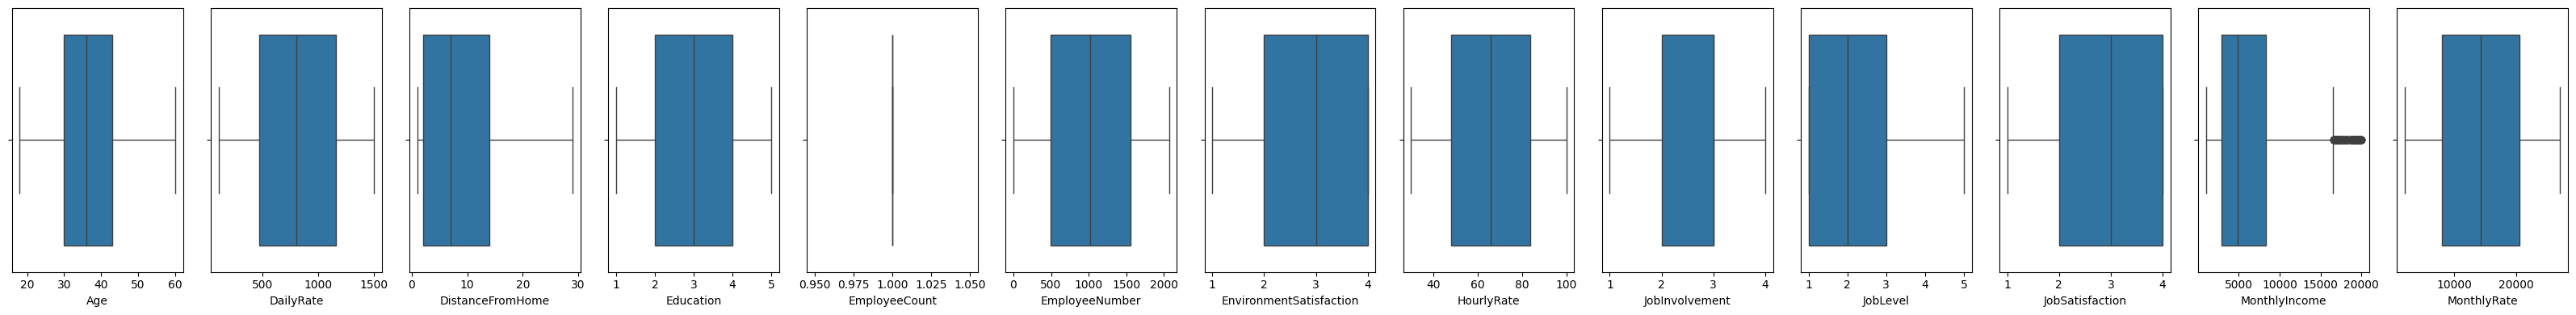

In [ ]:
fig, ax = plt.subplots(1, 13, figsize=(32, 4))

sns.boxplot(data, x='Age', ax=ax[0])
sns.boxplot(data, x='DailyRate', ax=ax[1])
sns.boxplot(data, x='DistanceFromHome', ax=ax[2])
sns.boxplot(data, x='Education', ax=ax[3])
sns.boxplot(data, x='EmployeeCount', ax=ax[4])
sns.boxplot(data, x='EmployeeNumber', ax=ax[5])
sns.boxplot(data, x='EnvironmentSatisfaction', ax=ax[6])
sns.boxplot(data, x='HourlyRate', ax=ax[7])
sns.boxplot(data, x='JobInvolvement', ax=ax[8])
sns.boxplot(data, x='JobLevel', ax=ax[9])
sns.boxplot(data, x='JobSatisfaction', ax=ax[10])
sns.boxplot(data, x='MonthlyIncome', ax=ax[11])
sns.boxplot(data, x='MonthlyRate', ax=ax[12])

plt.tight_layout()
plt.show()

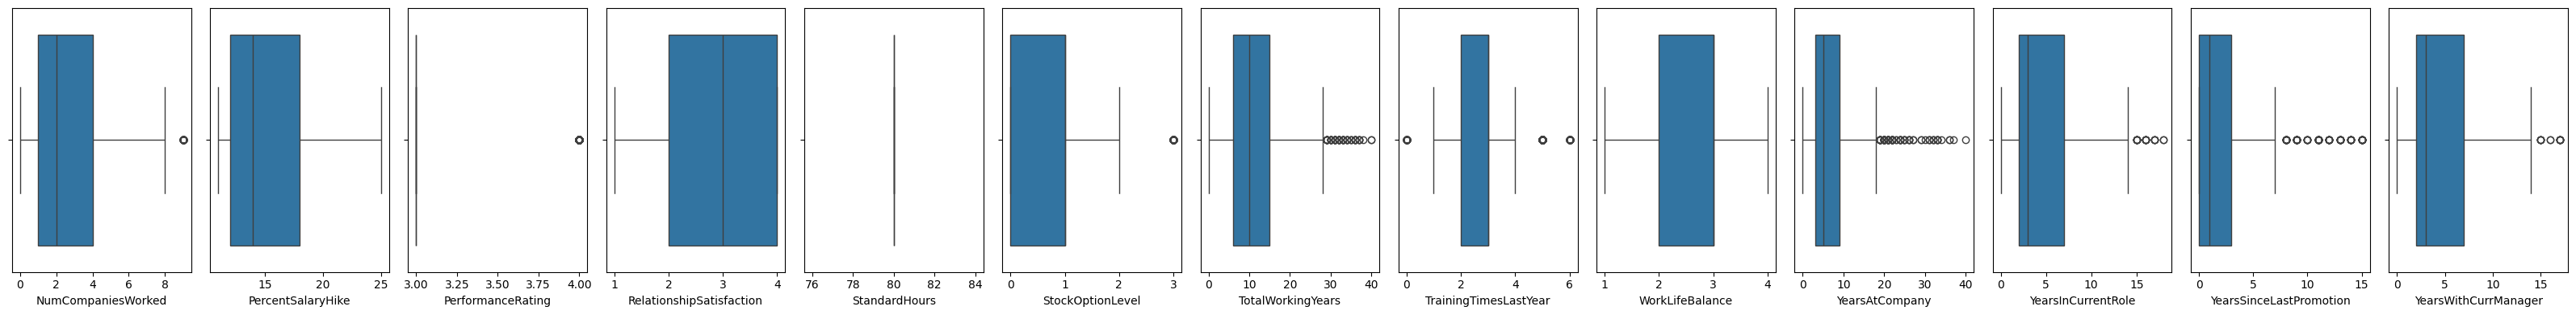

In [ ]:
fig, ax = plt.subplots(1, 13, figsize=(32, 4))

sns.boxplot(data, x='NumCompaniesWorked', ax=ax[0])
sns.boxplot(data, x='PercentSalaryHike', ax=ax[1])
sns.boxplot(data, x='PerformanceRating', ax=ax[2])
sns.boxplot(data, x='RelationshipSatisfaction', ax=ax[3])
sns.boxplot(data, x='StandardHours', ax=ax[4])
sns.boxplot(data, x='StockOptionLevel', ax=ax[5])
sns.boxplot(data, x='TotalWorkingYears', ax=ax[6])
sns.boxplot(data, x='TrainingTimesLastYear', ax=ax[7])
sns.boxplot(data, x='WorkLifeBalance', ax=ax[8])
sns.boxplot(data, x='YearsAtCompany', ax=ax[9])
sns.boxplot(data, x='YearsInCurrentRole', ax=ax[10])
sns.boxplot(data, x='YearsSinceLastPromotion', ax=ax[11])
sns.boxplot(data, x='YearsWithCurrManager', ax=ax[12])

plt.tight_layout()
plt.show()

Outliers are seen in MonthlyIncome,NumCompaniesWorked,PerformanceRating,
        StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,
        YearsAtCompany,YearsInCurrentRole,
        YearsSinceLastPromotion,YearsWithCurrManager

###3.Checking the distributon

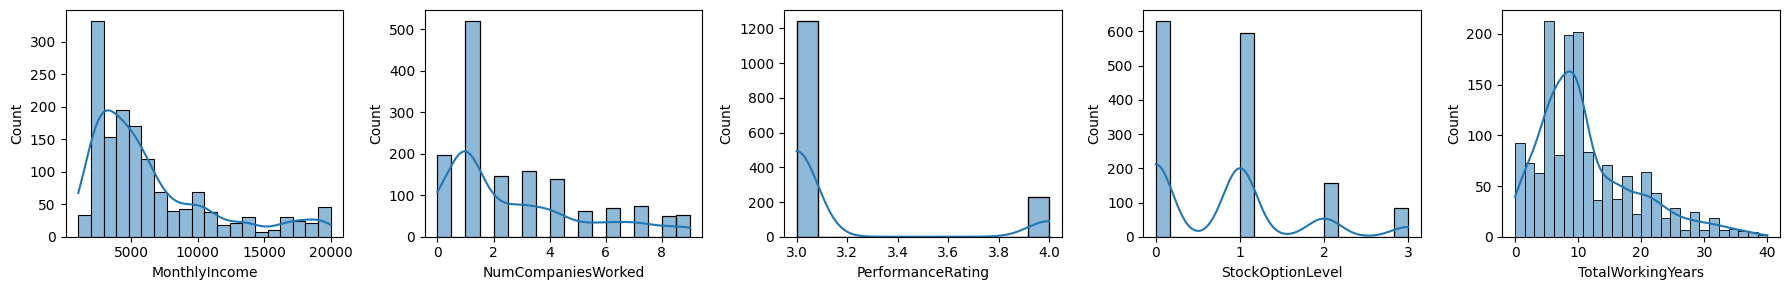

In [ ]:
#check the distribution
fig, ax = plt.subplots(1, 5, figsize=(18, 3))

sns.histplot(data, x='MonthlyIncome', ax=ax[0], kde=True)
sns.histplot(data, x='NumCompaniesWorked', ax=ax[1], kde=True)
sns.histplot(data, x='PerformanceRating', ax=ax[2], kde=True)
sns.histplot(data, x='StockOptionLevel', ax=ax[3], kde=True)
sns.histplot(data, x='TotalWorkingYears', ax=ax[4], kde=True)

plt.tight_layout()
plt.show()

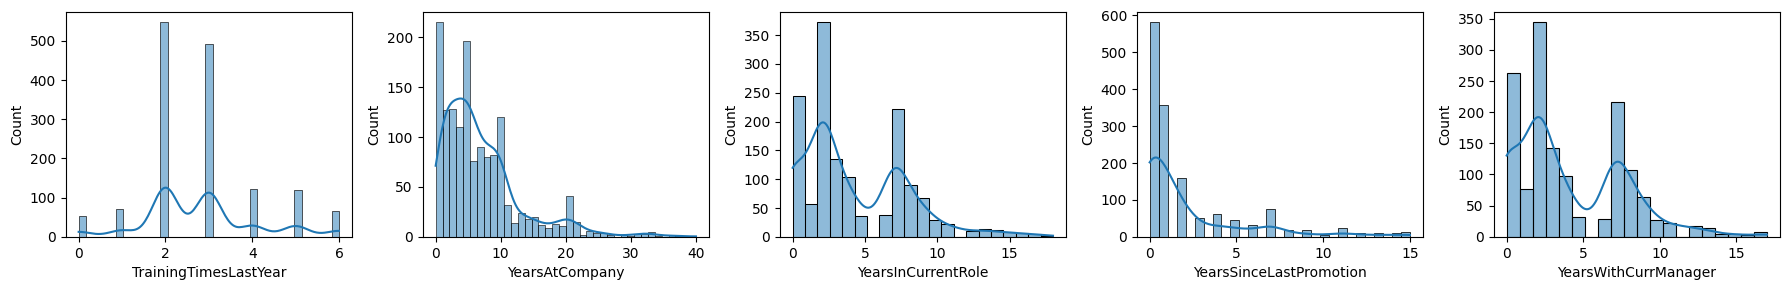

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(18, 3))

sns.histplot(data, x='TrainingTimesLastYear', ax=ax[0], kde=True)
sns.histplot(data, x='YearsAtCompany', ax=ax[1], kde=True)
sns.histplot(data, x='YearsInCurrentRole', ax=ax[2], kde=True)
sns.histplot(data, x='YearsSinceLastPromotion', ax=ax[3], kde=True)
sns.histplot(data, x='YearsWithCurrManager', ax=ax[4], kde=True)

plt.tight_layout()
plt.show()

In [ ]:
cols = ['MonthlyIncome','NumCompaniesWorked','PerformanceRating',
        'StockOptionLevel','TotalWorkingYears','TrainingTimesLastYear',
        'YearsAtCompany','YearsInCurrentRole',
        'YearsSinceLastPromotion','YearsWithCurrManager']

for x in cols:
    print(x, '-->', data[x].skew())
    print()

MonthlyIncome --> 1.3698166808390662

NumCompaniesWorked --> 1.026471111968205

PerformanceRating --> 1.921882702142603

StockOptionLevel --> 0.9689803167738937

TotalWorkingYears --> 1.1171718528128527

TrainingTimesLastYear --> 0.5531241710537028

YearsAtCompany --> 1.7645294543422085

YearsInCurrentRole --> 0.9173631562908262

YearsSinceLastPromotion --> 1.9842899833524859

YearsWithCurrManager --> 0.8334509919918475



all the values are right skewed
so we will use median

MonthlyIncome

In [ ]:
Q1 = data.loc[:,'MonthlyIncome'].quantile(0.25)
Q3 = data.loc[:,'MonthlyIncome'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [ ]:
data[(data.loc[:,'MonthlyIncome']>upper_limit)|(data.loc[:,'MonthlyIncome']<lower_limit)]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
25,53,No,Travel_Rarely,1282,Research & Development,5,3,Other,1,32,...,4,80,1,26,3,2,14,13,4,8
29,46,No,Travel_Rarely,705,Sales,2,4,Marketing,1,38,...,4,80,0,22,2,2,2,2,2,1
45,41,Yes,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,1,58,...,4,80,0,23,0,3,22,15,15,8
62,50,No,Travel_Rarely,989,Research & Development,7,2,Medical,1,80,...,4,80,1,29,2,2,27,3,13,8
105,59,No,Non-Travel,1420,Human Resources,2,4,Human Resources,1,140,...,4,80,1,30,3,3,3,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,58,No,Travel_Rarely,605,Sales,21,3,Life Sciences,1,1938,...,3,80,1,29,2,2,1,0,0,0
1377,49,No,Travel_Frequently,1064,Research & Development,2,1,Life Sciences,1,1941,...,4,80,0,28,3,3,5,4,4,3
1401,55,No,Travel_Rarely,189,Human Resources,26,4,Human Resources,1,1973,...,1,80,1,35,0,3,10,9,1,4
1437,39,No,Non-Travel,105,Research & Development,9,3,Life Sciences,1,2022,...,3,80,0,21,3,2,6,0,1,3


In [ ]:
len(data[(data.loc[:,'MonthlyIncome']>upper_limit)|(data.loc[:,'MonthlyIncome']<lower_limit)])/len(data)*100


7.755102040816326

####Since % of outliers is more than 5% will leave them as it is.

###**NumCompaniesWorked**

In [ ]:
Q1 = data.loc[:,'NumCompaniesWorked'].quantile(0.25)
Q3 = data.loc[:,'NumCompaniesWorked'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'NumCompaniesWorked']>upper_limit)|(data.loc[:,'NumCompaniesWorked']<lower_limit)]

len(data[(data.loc[:,'NumCompaniesWorked']>upper_limit)|(data.loc[:,'NumCompaniesWorked']<lower_limit)])/len(data)*100

3.537414965986395

####outliers was less than 5% we will replace with median.

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'NumCompaniesWorked']>upper_limit)|
 (data.loc[:,'NumCompaniesWorked']<lower_limit),'NumCompaniesWorked']=data.loc[:,'NumCompaniesWorked'].median()

In [ ]:
len(data[(data.loc[:,'NumCompaniesWorked']>upper_limit)|(data.loc[:,'NumCompaniesWorked']<lower_limit)])/len(data)*100

0.0

###PerformanceRating

In [ ]:
Q1 = data.loc[:,'PerformanceRating'].quantile(0.25)
Q3 = data.loc[:,'PerformanceRating'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'PerformanceRating']>upper_limit)|(data.loc[:,'PerformanceRating']<lower_limit)]

len(data[(data.loc[:,'PerformanceRating']>upper_limit)|(data.loc[:,'PerformanceRating']<lower_limit)])/len(data)*100

15.374149659863946

#### Since % of outliers is more than 5% will leave them as it is.

###StockOptionLevel

In [ ]:
Q1 = data.loc[:,'StockOptionLevel'].quantile(0.25)
Q3 = data.loc[:,'StockOptionLevel'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'StockOptionLevel']>upper_limit)|(data.loc[:,'StockOptionLevel']<lower_limit)]

len(data[(data.loc[:,'StockOptionLevel']>upper_limit)|(data.loc[:,'StockOptionLevel']<lower_limit)])/len(data)*100

5.782312925170068

#### Since % of outliers is more than 5% will leave them as it is.

##TotalWorkingYears

In [ ]:
Q1 = data.loc[:,'TotalWorkingYears'].quantile(0.25)
Q3 = data.loc[:,'TotalWorkingYears'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'TotalWorkingYears']>upper_limit)|(data.loc[:,'TotalWorkingYears']<lower_limit)]

len(data[(data.loc[:,'TotalWorkingYears']>upper_limit)|(data.loc[:,'TotalWorkingYears']<lower_limit)])/len(data)*100

4.285714285714286

####outliers was less than 5% we will replace with median.

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'TotalWorkingYears']>upper_limit)|
 (data.loc[:,'TotalWorkingYears']<lower_limit),'TotalWorkingYears']=data.loc[:,'TotalWorkingYears'].median()

In [ ]:
len(data[(data.loc[:,'TotalWorkingYears']>upper_limit)|(data.loc[:,'TotalWorkingYears']<lower_limit)])/len(data)*100

0.0

###TrainingTimesLastYear

In [ ]:
Q1 = data.loc[:,'TrainingTimesLastYear'].quantile(0.25)
Q3 = data.loc[:,'TrainingTimesLastYear'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'TrainingTimesLastYear']>upper_limit)|(data.loc[:,'TrainingTimesLastYear']<lower_limit)]

len(data[(data.loc[:,'TrainingTimesLastYear']>upper_limit)|(data.loc[:,'TrainingTimesLastYear']<lower_limit)])/len(data)*100

16.19047619047619

# Since % of outliers is more than 5% will leave them as it is.

###YearsAtCompany

In [ ]:
Q1 = data.loc[:,'YearsAtCompany'].quantile(0.25)
Q3 = data.loc[:,'YearsAtCompany'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'YearsAtCompany']>upper_limit)|(data.loc[:,'YearsAtCompany']<lower_limit)]

len(data[(data.loc[:,'YearsAtCompany']>upper_limit)|(data.loc[:,'YearsAtCompany']<lower_limit)])/len(data)*100


7.07482993197279

####Since % of outliers is more than 5% will leave them as it is.

###YearsInCurrentRole

In [ ]:
Q1 = data.loc[:,'YearsInCurrentRole'].quantile(0.25)
Q3 = data.loc[:,'YearsInCurrentRole'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'YearsInCurrentRole']>upper_limit)|(data.loc[:,'YearsInCurrentRole']<lower_limit)]

len(data[(data.loc[:,'YearsInCurrentRole']>upper_limit)|(data.loc[:,'YearsInCurrentRole']<lower_limit)])/len(data)*100

1.4285714285714286

####outliers was less than 5% we will replace with median.

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'YearsInCurrentRole']>upper_limit)|
 (data.loc[:,'YearsInCurrentRole']<lower_limit),'YearsInCurrentRole']=data.loc[:,'YearsInCurrentRole'].median()

In [ ]:
len(data[(data.loc[:,'YearsInCurrentRole']>upper_limit)|(data.loc[:,'YearsInCurrentRole']<lower_limit)])/len(data)*100

0.0

###YearsSinceLastPromotion

In [ ]:
Q1 = data.loc[:,'YearsSinceLastPromotion'].quantile(0.25)
Q3 = data.loc[:,'YearsSinceLastPromotion'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'YearsSinceLastPromotion']>upper_limit)|(data.loc[:,'YearsSinceLastPromotion']<lower_limit)]

len(data[(data.loc[:,'YearsSinceLastPromotion']>upper_limit)|(data.loc[:,'YearsSinceLastPromotion']<lower_limit)])/len(data)*100

7.278911564625851

#### Since % of outliers is more than 5% will leave them as it is.

###YearsWithCurrManager

In [ ]:
Q1 = data.loc[:,'YearsWithCurrManager'].quantile(0.25)
Q3 = data.loc[:,'YearsWithCurrManager'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

data[(data.loc[:,'YearsWithCurrManager']>upper_limit)|(data.loc[:,'YearsWithCurrManager']<lower_limit)]

len(data[(data.loc[:,'YearsWithCurrManager']>upper_limit)|(data.loc[:,'YearsWithCurrManager']<lower_limit)])/len(data)*100

0.9523809523809524

####outliers was less than 5% we will replace with median.

In [ ]:
# since % of outliers is less than 5% lets replace with median(distribution is skewed)
data.loc[(data.loc[:,'YearsWithCurrManager']>upper_limit)|
 (data.loc[:,'YearsWithCurrManager']<lower_limit),'YearsWithCurrManager']=data.loc[:,'YearsWithCurrManager'].median()

In [ ]:
len(data[(data.loc[:,'YearsWithCurrManager']>upper_limit)|(data.loc[:,'YearsWithCurrManager']<lower_limit)])/len(data)*100

0.0

### 10. Encoding

In [ ]:
cat_cols = data.select_dtypes(include='object').columns
cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


# 1. Label Encoding

data['Attrition'] = le.fit_transform(data['Attrition'])
data['Gender'] = le.fit_transform(data['Gender'])
data['OverTime'] = le.fit_transform(data['OverTime'])




# 3. One-Hot Encoding
data = pd.get_dummies(data,
                      columns=['BusinessTravel', 'Department',
                               'EducationField', 'JobRole', 'MaritalStatus'],
                      drop_first=True)


# 4. Final Check

print(data.head())
print(data.shape)

   Age  Attrition  DailyRate  DistanceFromHome  Education  EmployeeCount  \
0   41          1       1102                 1          2              1   
1   49          0        279                 8          1              1   
2   37          1       1373                 2          2              1   
3   33          0       1392                 3          4              1   
4   27          0        591                 2          1              1   

   EmployeeNumber  EnvironmentSatisfaction  Gender  HourlyRate  ...  \
0               1                        2       0          94  ...   
1               2                        3       1          61  ...   
2               4                        4       1          92  ...   
3               5                        4       0          56  ...   
4               7                        1       1          40  ...   

   JobRole_Human Resources  JobRole_Laboratory Technician  JobRole_Manager  \
0                    False            

###11.Scaling

In [ ]:
# Separate X and y
X = data.drop('Attrition', axis=1)
y = data['Attrition']

# Drop irrelevant columns before scaling
X = X.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], errors='ignore')

### 12. Separate Features and Target Variable

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame with original column names
X = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


###13. Perform Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1176, 44) (294, 44)


###14. Balance data : SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train.value_counts())

After SMOTE: Attrition
0    978
1    978
Name: count, dtype: int64


###15. Train Classification Models

In [ ]:
# 1. Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)


# 2. Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


# 3. Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)


# 4. KNN

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)

###16. Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    "Logistic Regression": (lr, y_pred_lr),
    "Decision Tree": (dt, y_pred_dt),
    "Random Forest": (rf, y_pred_rf),
    "KNN": (knn, y_pred_knn)
}

results = {}

for name, (model, y_pred) in models.items():

    # Get probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:,1]

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    # Store results
    results[name] = [acc, prec, rec, f1, roc]



# Corrected loop to use original model names and their predictions for printing
for name, (model, y_pred_val) in models.items(): # Use original 'models' dict
    print(f"\n--- {name} Metrics ---")
    print(f"Accuracy: {results[name][0]:.4f}")
    print(f"Precision: {results[name][1]:.4f}")
    print(f"Recall: {results[name][2]:.4f}")
    print(f"F1 Score: {results[name][3]:.4f}")
    print(f"ROC-AUC: {results[name][4]:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_val))


--- Logistic Regression Metrics ---
Accuracy: 0.7517
Precision: 0.2821
Recall: 0.5641
F1 Score: 0.3761
ROC-AUC: 0.7487
Confusion Matrix:
 [[199  56]
 [ 17  22]]

--- Decision Tree Metrics ---
Accuracy: 0.7857
Precision: 0.2391
Recall: 0.2821
F1 Score: 0.2588
ROC-AUC: 0.5724
Confusion Matrix:
 [[220  35]
 [ 28  11]]

--- Random Forest Metrics ---
Accuracy: 0.8741
Precision: 0.5833
Recall: 0.1795
F1 Score: 0.2745
ROC-AUC: 0.7531
Confusion Matrix:
 [[250   5]
 [ 32   7]]

--- KNN Metrics ---
Accuracy: 0.6633
Precision: 0.2273
Recall: 0.6410
F1 Score: 0.3356
ROC-AUC: 0.6775
Confusion Matrix:
 [[170  85]
 [ 14  25]]


###17.  Cross Validation

In [ ]:
# Models
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}

cv_results = {}

for name, model in models.items():

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    cv_results[name] = scores.mean()

    print(f"{name} CV Scores:", scores)
    print(f"{name} Mean CV Score:", scores.mean())
    print("-"*40)

cv_df = pd.DataFrame(cv_results, index=["Mean Accuracy"]).T

print("\nCross Validation Results:")
print(cv_df)

Logistic Regression CV Scores: [0.81632653 0.85421995 0.83375959 0.8056266  0.80306905]
Logistic Regression Mean CV Score: 0.8226003444856204
----------------------------------------
Decision Tree CV Scores: [0.69897959 0.88235294 0.89002558 0.9028133  0.89258312]
Decision Tree Mean CV Score: 0.8533509055796232
----------------------------------------
Random Forest CV Scores: [0.7372449  0.9769821  0.96930946 0.96163683 0.97953964]
Random Forest Mean CV Score: 0.924942585729944
----------------------------------------
KNN CV Scores: [0.76530612 0.81585678 0.8056266  0.81585678 0.81329923]
KNN Mean CV Score: 0.8031891017276476
----------------------------------------

Cross Validation Results:
                     Mean Accuracy
Logistic Regression       0.822600
Decision Tree             0.853351
Random Forest             0.924943
KNN                       0.803189


###18.Hyperparameter Tuning

In [ ]:


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


# Logistic Regression

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {'C': [0.01, 0.1, 1, 10]},
    cv=5,
    scoring='accuracy'
)
lr_grid.fit(X_train, y_train)


# Decision Tree

dt_grid = GridSearchCV(
    DecisionTreeClassifier(),
    {'max_depth': [5, 10, 15],
     'min_samples_split': [2, 5]},
    cv=5,
    scoring='accuracy'
)
dt_grid.fit(X_train, y_train)


# Random Forest (GridSearch)

rf_grid = GridSearchCV(
    RandomForestClassifier(),
    {'n_estimators': [50, 100],
     'max_depth': [5, 10]},
    cv=5,
    scoring='accuracy'
)
rf_grid.fit(X_train, y_train)


# Random Forest (RandomizedSearch)

rf_rand = RandomizedSearchCV(
    RandomForestClassifier(),
    {'n_estimators': [50, 100, 200],
     'max_depth': [5, 10, 15]},
    n_iter=5,
    cv=5,
    scoring='accuracy',
    random_state=42
)
rf_rand.fit(X_train, y_train)

# KNN

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7]},
    cv=5,
    scoring='accuracy'
)
knn_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7]}, scoring='accuracy')

In [ ]:
print("\n--- Hyperparameter Tuning Results ---")

print("Logistic Regression Best Params:", lr_grid.best_params_)
print("Logistic Regression Best Score:", lr_grid.best_score_)

print("\nDecision Tree Best Params:", dt_grid.best_params_)
print("Decision Tree Best Score:", dt_grid.best_score_)

print("\nRandom Forest (Grid) Best Params:", rf_grid.best_params_)
print("Random Forest (Grid) Best Score:", rf_grid.best_score_)

print("\nRandom Forest (Random) Best Params:", rf_rand.best_params_)
print("Random Forest (Random) Best Score:", rf_rand.best_score_)

print("\nKNN Best Params:", knn_grid.best_params_)
print("KNN Best Score:", knn_grid.best_score_)


--- Hyperparameter Tuning Results ---
Logistic Regression Best Params: {'C': 1}
Logistic Regression Best Score: 0.8226003444856204

Decision Tree Best Params: {'max_depth': 10, 'min_samples_split': 2}
Decision Tree Best Score: 0.856419959288063

Random Forest (Grid) Best Params: {'max_depth': 10, 'n_estimators': 100}
Random Forest (Grid) Best Score: 0.9228965499243176

Random Forest (Random) Best Params: {'n_estimators': 100, 'max_depth': 15}
Random Forest (Random) Best Score: 0.9341380030272978

KNN Best Params: {'n_neighbors': 3}
KNN Best Score: 0.8338639803747586


###19. Compare Model Performance

In [ ]:

#  BEFORE results table

results_df = pd.DataFrame(results,
index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]).T

print("\nBefore Tuning:")
print(results_df)


# After Tuning Evaluation

models_after = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_
}

results_after = {}

for name, model in models_after.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    results_after[name] = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]

results_after_df = pd.DataFrame(results_after,
index=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]).T

print("\nAfter Tuning:")
print(results_after_df)


# FINAL COMPARISON


before = results_df.copy()
before.columns = [col + "_Before" for col in before.columns]

after = results_after_df.copy()
after.columns = [col + "_After" for col in after.columns]

comparison_df = pd.concat([before, after], axis=1)

print("\nFinal Comparison Table:")
print(comparison_df)


Before Tuning:
                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.751701   0.282051  0.564103  0.376068  0.748718
Decision Tree        0.785714   0.239130  0.282051  0.258824  0.572398
Random Forest        0.874150   0.583333  0.179487  0.274510  0.753092
KNN                  0.663265   0.227273  0.641026  0.335570  0.677476

After Tuning:
                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.751701   0.282051  0.564103  0.376068  0.748718
Decision Tree        0.772109   0.195652  0.230769  0.211765  0.528758
Random Forest        0.880952   0.666667  0.205128  0.313725  0.736350
KNN                  0.700680   0.230769  0.538462  0.323077  0.659930

Final Comparison Table:
                     Accuracy_Before  Precision_Before  Recall_Before  \
Logistic Regression         0.751701          0.282051       0.564103   
Decision Tree               0.785714          0.239130       0.282051   
Random Forest  

In [ ]:
# Create comparison table
results_df = pd.DataFrame(results,
                          index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]).T

print("\nModel Comparison Table:")
print(results_df)


Model Comparison Table:
                     Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression  0.751701   0.282051  0.564103  0.376068  0.748718
Decision Tree        0.785714   0.239130  0.282051  0.258824  0.572398
Random Forest        0.874150   0.583333  0.179487  0.274510  0.753092
KNN                  0.663265   0.227273  0.641026  0.335570  0.677476


###   20: Select Best Model

####  Based on Metrics

Among all the models tested, **Logistic Regression** is selected as the best-performing model.

- It provides a good balance between **Precision** and **Recall**
- It has relatively **higher Recall**, which is important for detecting employees likely to leave  
- It achieves a better **F1 Score**, indicating balanced performance  
- The **ROC-AUC score** shows good classification ability  

Although **Random Forest** may have higher accuracy, its **low Recall** makes it less suitable for this problem.

---

####  Business Interpretation

In employee attrition prediction, the goal is to identify employees who are likely to leave.

Missing such employees (**low Recall**) can result in:

- Increased hiring costs  
- Loss of skilled employees  
- Reduced productivity  

**Logistic Regression is best because:**

- It identifies more employees at risk  
- Maintains a balance between false positives and false negatives  
- Provides simple and interpretable results for HR decision-making  

---

###   21: Final Insights & Recommendations

####  Key Factors Influencing Attrition

Based on analysis:

- **Monthly Income** → Lower salary leads to higher attrition  
- **OverTime** → Employees working overtime are more likely to leave  
- **Job Satisfaction** → Low satisfaction increases attrition  
- **Work-Life Balance** → Poor balance leads to employee turnover  
- **Total Working Years** → Less experienced employees leave more  
- **Years at Company** → New employees have higher attrition  
- **Age** → Younger employees tend to switch jobs more  

---

####  Business Recommendations

- Improve salary and incentives  
- Reduce excessive overtime  
- Increase job satisfaction (feedback systems)  
- Promote work-life balance  
- Focus on early-career employees  
- Provide career growth opportunities  
- Conduct employee engagement programs  

---
